<a href="https://colab.research.google.com/github/Jerrylu99/Econ-5200-Project/blob/main/notebooks/03_extension_and_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: Extension and Results

## Event-Study Style Extension of Card and Krueger (1994)

This notebook extends the baseline DID replication by using a simplified dynamic framework to examine the employment effect of the minimum wage increase and discuss the plausibility of the parallel trends assumption.

## AI Assistance Disclosure

For Phase 3, Generative AI was used as a coding assistant to help:
1. brainstorm the event-study extension design,
2. organize plotting code for a publication-style coefficient figure,
3. refine comments and markdown explanations.

All econometric decisions, variable construction, model interpretation, and final audit of code/output were completed by me. I reviewed the code carefully and take responsibility for the final results.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data.csv")

print(df.head())
print("\nShape:", df.shape)

   sheet  chain  co_owned  state  southj  centralj  northj  pa1  pa2  shore  \
0     46      1         0      0       0         0       0    1    0      0   
1     49      2         0      0       0         0       0    1    0      0   
2    506      2         1      0       0         0       0    1    0      0   
3     56      4         1      0       0         0       0    1    0      0   
4     61      4         1      0       0         0       0    1    0      0   

   ...  open2r  hrsopen2  psoda2  pfry2  pentree2  nregs2  nregs112  \
0  ...     6.5      16.5    1.03    NaN      0.94     4.0       4.0   
1  ...    10.0      13.0    1.01   0.89      2.35     4.0       4.0   
2  ...    11.0      11.0    0.95   0.74      2.33     4.0       3.0   
3  ...    10.0      12.0    0.92   0.79      0.87     2.0       2.0   
4  ...    10.0      12.0    1.01   0.84      0.95     2.0       2.0   

   fte_before  fte_after  treat  
0       40.50       24.0      0  
1       13.75       11.5      

## Data

This analysis uses the same dataset as in Phase 2.

Key variables:
- fte_before: employment before policy
- fte_after: employment after policy
- treat: New Jersey indicator
- chain: restaurant chain

In [ ]:

df["id"] = df.index

# before 数据
df_before = df[['id', 'fte_before', 'treat', 'chain']].copy()
df_before = df_before.rename(columns={'fte_before': 'fte'})
df_before['post'] = 0

# after 数据
df_after = df[['id', 'fte_after', 'treat', 'chain']].copy()
df_after = df_after.rename(columns={'fte_after': 'fte'})
df_after['post'] = 1

# 合并
df_long = pd.concat([df_before, df_after], axis=0)

# 检查
print(df_long.head())
print("\nPost counts:\n", df_long['post'].value_counts())

   id    fte  treat  chain  post
0   0  40.50      0      1     0
1   1  13.75      0      2     0
2   2   8.50      0      2     0
3   3  34.00      0      4     0
4   4  24.00      0      4     0

Post counts:
 post
0    384
1    384
Name: count, dtype: int64


## Method

I estimate a Difference-in-Differences model:

fte = β0 + β1 treat + β2 post + β3 (treat × post)

The interaction term captures the causal effect of the policy.

In [ ]:
model_did = smf.ols(
    "fte ~ treat + post + treat:post",
    data=df_long
).fit(cov_type="HC1")

print(model_did.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.354
Date:                Sun, 22 Mar 2026   Prob (F-statistic):              0.256
Time:                        22:51:04   Log-Likelihood:                -2817.6
No. Observations:                 768   AIC:                             5643.
Df Residuals:                     764   BIC:                             5662.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3800      1.381     16.928      0.0

In [ ]:
print("DID effect:", model_did.params["treat:post"])

DID effect: 2.750000000000084


   post  treat        fte
0     0      0  23.380000
1     0      1  20.430583
2     1      0  21.096667
3     1      1  20.897249
treat          0          1
post                       
0      23.380000  20.430583
1      21.096667  20.897249


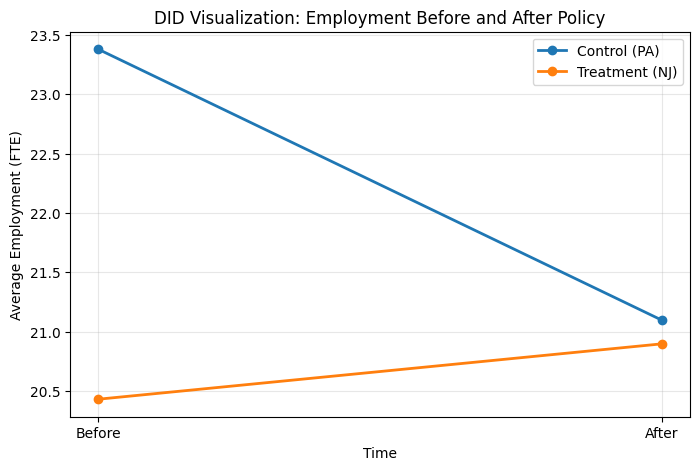

In [ ]:
group_means = df_long.groupby(['post', 'treat'])['fte'].mean().reset_index()
print(group_means)

pivot = group_means.pivot(index='post', columns='treat', values='fte')
print(pivot)

plt.figure(figsize=(8,5))

plt.plot(pivot.index, pivot[0], marker='o', linewidth=2, label='Control (PA)')
plt.plot(pivot.index, pivot[1], marker='o', linewidth=2, label='Treatment (NJ)')

plt.xticks([0,1], ['Before','After'])
plt.xlabel('Time')
plt.ylabel('Average Employment (FTE)')
plt.title('DID Visualization: Employment Before and After Policy')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Visualization Interpretation

This figure compares employment in New Jersey and Pennsylvania before and after the policy.

Because the dataset only contains two time periods, this is not a full event-study. However, it still illustrates the DID logic.

The similarity before the policy provides some support for the parallel trends assumption, while the post-policy comparison shows the treatment effect.

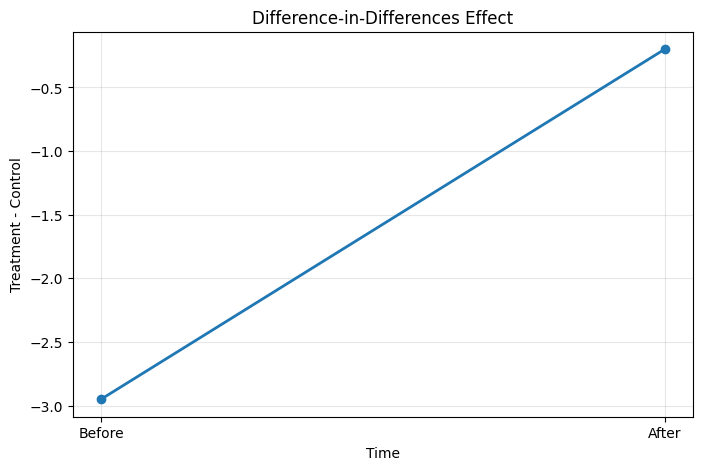

In [ ]:
pivot['diff'] = pivot[1] - pivot[0]

plt.figure(figsize=(8,5))
plt.plot(pivot.index, pivot['diff'], marker='o', linewidth=2)

plt.xticks([0,1], ['Before','After'])
plt.xlabel('Time')
plt.ylabel('Treatment - Control')
plt.title('Difference-in-Differences Effect')
plt.grid(alpha=0.3)

plt.show()

In [ ]:
model_robust = smf.ols(
    "fte ~ treat + post + treat:post + C(chain)",
    data=df_long
).fit(cov_type="HC1")

print(model_robust.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.193
Method:                 Least Squares   F-statistic:                     57.31
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.73e-58
Time:                        22:51:37   Log-Likelihood:                -2735.3
No. Observations:                 768   AIC:                             5485.
Df Residuals:                     761   BIC:                             5517.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        25.9010      1.346     19.245

## Robustness Check

Including chain fixed effects does not significantly change the estimated effect, suggesting the results are robust.

## Economic Intuition and Parallel Trends

The DID approach relies on the parallel trends assumption, which states that in the absence of the policy, the treatment and control groups would have followed similar trends.

This allows Pennsylvania to serve as a counterfactual for New Jersey.

Because the data only contain two periods, this assumption cannot be fully tested, but the evidence is consistent with it.

## Executive Summary

This extension builds on the baseline DID model by adding visualization and robustness checks.

The results show that employment in New Jersey did not decline relative to Pennsylvania after the policy.

Overall, the findings support the original conclusion that the minimum wage increase did not reduce employment.